# Figure 02 -- force error vs opening angle

Loads `results/validation/error_vs_theta.json`, produced by `bench/validation/error_vs_theta.py`. No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.repo_root() / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


wrote /export/home/tbuck/jaccpot-paper-wt/results/figures/fig02_error_vs_theta.pdf


'/export/home/tbuck/jaccpot-paper-wt/results/figures/fig02_error_vs_theta.pdf'

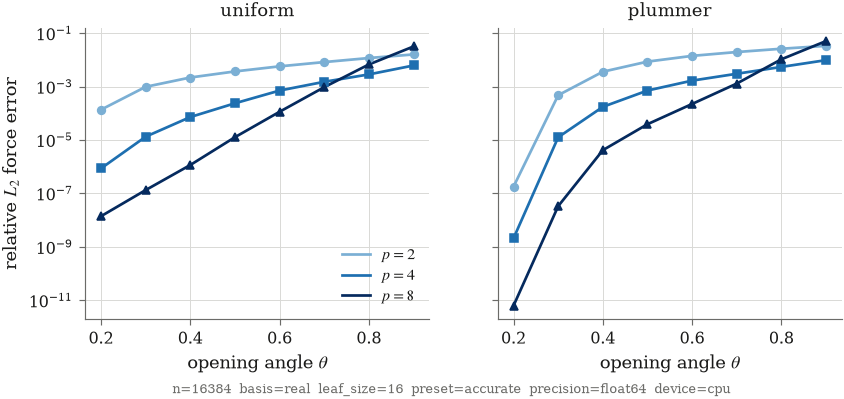

In [2]:
art = jsonio.read_result("validation/error_vs_theta.json")
cfg, recs = art["config"], art["data"]["records"]

dists = list(cfg["distribution"])
orders = sorted({r["order"] for r in recs})
# Order is an ORDERED axis, so it gets the sequential ramp, not categorical hues.
ramp = style.sequential_colors(len(orders))

fig, axes = style.figure(
    width=style.TWO_COL, height=2.7, ncols=len(dists), sharey=True
)
axes = np.atleast_1d(axes)

for ax, dist in zip(axes, dists):
    for oi, order in enumerate(orders):
        sel = sorted(
            (r for r in recs if r["distribution"] == dist and r["order"] == order),
            key=lambda r: r["theta"],
        )
        if not sel:
            continue
        theta = [r["theta"] for r in sel]
        err = [r["rel_l2"] for r in sel]
        ax.plot(theta, err, "-", color=ramp[oi], label=f"$p={order}$", zorder=3)
        # Split the markers: a filled point had a far field to approximate, an
        # open one did not, and its error is round-off rather than convergence.
        empty = [r.get("far_field_empty", False) for r in sel]
        for filled, marker_set in ((False, "filled"), (True, "open")):
            xs = [t for t, e in zip(theta, empty) if e == filled]
            ys = [v for v, e in zip(err, empty) if e == filled]
            if not xs:
                continue
            ax.plot(
                xs, ys, style.MARKERS[oi % len(style.MARKERS)],
                color=ramp[oi], zorder=4,
                markerfacecolor=("white" if filled else ramp[oi]),
                markeredgecolor=ramp[oi],
            )
    ax.set_yscale("log")
    ax.set_xlabel(r"opening angle $\theta$")
    ax.set_title(dist, fontsize=9)
    style.finish(ax, legend=(ax is axes[0]), legend_kwargs={"loc": "lower right"})
axes[0].set_ylabel("relative $L_2$ force error")

if any(r.get("far_field_empty") for r in recs):
    axes[0].text(
        0.02, 0.98,
        "open marker: far field empty\n(exact P2P; error is round-off)",
        transform=axes[0].transAxes, va="top", ha="left",
        fontsize=6.5, color=style.INK_MUTED,
    )
style.footer(
    fig,
    jsonio.config_caption(cfg, ["n", "basis", "leaf_size", "preset", "precision", "device"]),
)
style.save(fig, FIG_DIR / "fig02_error_vs_theta.pdf")


## Caption

Relative $L_2$ force error against opening angle $\theta$ at fixed $N$, with
expansion orders overlaid (light to dark), for a uniform cube and a Plummer
sphere. Orders use a single-hue sequential ramp because $p$ is an ordered
quantity. **Open markers mark configurations whose far field is empty**: there the
solver has degenerated to an exact P2P direct sum, so the error is float64
round-off and says nothing about the expansion -- a flat low-$\theta$ tail would
otherwise read as convergence. Values from
`results/validation/error_vs_theta.json`.
